## VLM 교사 지도 감독 파인튜닝
Supervised Fine-Tuning (SFT) with Teacher Forcing

 디바이스 및 하이퍼파라미터 설정

In [ ]:
import torch
from PIL import Image
import requests
import matplotlib.pyplot as plt
from transformers import AutoProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Salesforce/blip-image-captioning-base" # https://huggingface.co/Salesforce/blip-image-captioning-base
learning_rate = 5e-5
epochs = 8

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu118 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0316 15:59:55.993000 24412 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


VLM 모델과 프로세서 로드

In [2]:
print("모델 로드 중...")
processor = AutoProcessor.from_pretrained(model_id)
model = BlipForConditionalGeneration.from_pretrained(model_id).to(device)


모델 로드 중...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


실습용 온라인 이미지 로드 (강아지가 해변에 있는 사진)

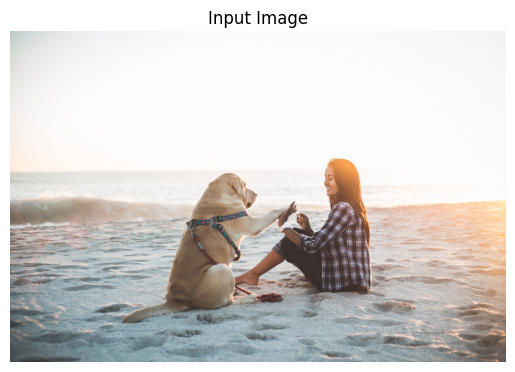

[학습 전 모델 추론]
원본 예측: a woman sitting on the beach with her dog


In [3]:
img_url = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()

# 4. 학습 전 모델 추론 (Baseline)
model.eval()
inputs = processor(image, return_tensors="pt").to(device)

with torch.no_grad():
    out_ids = model.generate(**inputs, repetition_penalty=1.5, no_repeat_ngram_size=3)
    before_text = processor.decode(out_ids[0], skip_special_tokens=True)

print("[학습 전 모델 추론]")
print(f"원본 예측: {before_text}")

커스텀 데이터 준비 (파인튜닝 목표 데이터 설정)

In [ ]:
target_text = "A magical photo of a golden dog relaxing on the beautiful beach."
print(f"학습 목표(Target): {target_text}\n")

# Vision Encoder Freeze
# 이미지 인코더는 이미 충분히 학습되어 있으므로 고정하고, 캡션을 생성하는 텍스트 디코더 파라미터만 업데이트함.
# 학습 파라미터 수 대폭 감소, 단일 샘플 과적합 억제함.
for param in model.vision_model.parameters():
    param.requires_grad = False
model.train() # 텍스트 디코더 파라미터만 업데이트하도록 설정

# 고정되지 않은 파라미터(텍스트 디코더)만 옵티마이저에 전달
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Cosine LR Scheduler 설정. 학습률을 코사인 곡선으로 점진 감소. 후반부 overshooting 방지
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 학습용 입력 데이터 전처리
train_inputs = processor(images=image, text=target_text, return_tensors="pt", padding=True).to(device)
train_inputs["labels"] = train_inputs["input_ids"].clone()


학습 목표(Target): A magical photo of a golden dog relaxing on the beautiful beach.

--- [모델 파인튜닝 시작] ---


VLM 모델 학습(SFT with Teacher Forcing)

In [ ]:
print("[모델 파인튜닝 시작]")

for epoch in range(epochs):
    outputs = model(**train_inputs)
    loss = outputs.loss

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    scheduler.step()

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}  LR: {scheduler.get_last_lr()[0]:.2e}")

print("[모델 파인튜닝 완료]")

Epoch 1/8 - Loss: 3.9002  LR: 4.81e-05
Epoch 2/8 - Loss: 2.1436  LR: 4.27e-05
Epoch 3/8 - Loss: 1.6225  LR: 3.46e-05
Epoch 4/8 - Loss: 1.2967  LR: 2.50e-05
Epoch 5/8 - Loss: 1.0275  LR: 1.54e-05
Epoch 6/8 - Loss: 0.8654  LR: 7.32e-06
Epoch 7/8 - Loss: 0.8246  LR: 1.90e-06
Epoch 8/8 - Loss: 0.8098  LR: 0.00e+00
[모델 파인튜닝 완료]


학습 후 모델 추론 (결과 확인)

In [6]:
model.eval()
with torch.no_grad():
    test_inputs = processor(image, return_tensors="pt").to(device)
    out_ids = model.generate(**test_inputs, repetition_penalty=1.5, no_repeat_ngram_size=3)
    after_text = processor.decode(out_ids[0], skip_special_tokens=True)

print("[학습 후 모델 추론]")
print(f"학습된 예측: {after_text}")

[학습 후 모델 추론]
학습된 예측: a magical photo of the golden dog relaxing on the beautiful beach sunset
